# SniffTest Train Notebook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/skrript/sniff-test/blob/main/snifftest_train.ipynb)

Self-contained GRPO training notebook for SniffTest. Uses Unsloth's standard `reward_funcs` API (no custom `rollout_func`). The model generates a **full action sequence** in one shot; reward functions evaluate that sequence against the environment.


## 1. Install

In [1]:
%%capture
import os, sys
# Install Unsloth + training stack
!pip install -qqq "unsloth[colab-new]" "trl>=0.17.0" "peft>=0.19.1" "accelerate>=1.13.0" "datasets>=3.6.0" "bitsandbytes>=0.45.0" matplotlib python-dotenv


## 2. Clone repo & install package

In [2]:
import os, sys, subprocess, socket, time, signal, atexit
from pathlib import Path

REPO_URL = os.getenv("SNIFFTEST_REPO_URL", "https://github.com/skrript/sniff-test.git")
WORKSPACE = Path.cwd().resolve()
REPO_DIR = (WORKSPACE if (WORKSPACE/"pyproject.toml").exists() else WORKSPACE/"sniff-test")
BASE_URL  = os.getenv("SNIFFTEST_BASE_URL", "http://127.0.0.1:8000")
MODEL_NAME = os.getenv("SNIFFTEST_MODEL_NAME", "Qwen/Qwen2.5-1.5B-Instruct")
ARTIFACT_DIR = (REPO_DIR / "temp/snifftest_train")

if not REPO_DIR.exists():
    subprocess.run(["git","clone",REPO_URL,str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable,"-m","pip","install","-q","-e","."], check=True)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print("Repo:", REPO_DIR)
print("Model:", MODEL_NAME)


Cloning into '/kaggle/working/sniff-test'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.5/213.5 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.3/152.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 6.3 MB/s eta 0:00:00
Repo: /kaggle/working/sniff-test
Model: Qwen/Qwen2.5-1.5B-Instruct


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.


## 3. HuggingFace login

In [3]:
import os
HF_TOKEN = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_HUB_TOKEN")
if not HF_TOKEN:
    from huggingface_hub import notebook_login
    notebook_login()
    HF_TOKEN = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_HUB_TOKEN")
if HF_TOKEN:
    os.environ.setdefault("HF_TOKEN", HF_TOKEN)
    os.environ.setdefault("HUGGINGFACE_HUB_TOKEN", HF_TOKEN)
print("HF token configured:", bool(HF_TOKEN))


HF token configured: False


## 4. Load model (Unsloth)

In [4]:
import torch
from unsloth import FastLanguageModel

MAX_SEQ_LENGTH = int(os.getenv("SNIFFTEST_MAX_SEQ_LENGTH", "2048"))
LORA_RANK      = int(os.getenv("SNIFFTEST_LORA_RANK", "16"))
LOAD_IN_4BIT   = os.getenv("SNIFFTEST_LOAD_IN_4BIT","1").lower() in {"1","true","yes"}

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = MODEL_NAME,
    max_seq_length= MAX_SEQ_LENGTH,
    load_in_4bit  = LOAD_IN_4BIT,
)
model = FastLanguageModel.get_peft_model(
    model,
    r                        = LORA_RANK,
    target_modules           = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha               = LORA_RANK * 2,
    lora_dropout             = 0,
    bias                     = "none",
    use_gradient_checkpointing= "unsloth",
    random_state             = 42,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("Model loaded:", MODEL_NAME)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/1.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.5.2 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model loaded: Qwen/Qwen2.5-1.5B-Instruct


## 5. Start environment server

In [5]:
SERVER_PROCESS = None

def _port(url):
    from urllib.parse import urlparse
    p = urlparse(url).port
    return p or (443 if url.startswith("https") else 80)

SERVER_PORT = _port(BASE_URL)

def start_server():
    global SERVER_PROCESS
    if SERVER_PROCESS and SERVER_PROCESS.poll() is None:
        return
    env = {**os.environ, "PYTHONPATH": str(REPO_DIR)}
    SERVER_PROCESS = subprocess.Popen(
        [sys.executable,"-m","uvicorn","server.app:app","--host","127.0.0.1","--port",str(SERVER_PORT)],
        cwd=REPO_DIR, env=env, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
    )
    deadline = time.time() + 30
    while time.time() < deadline:
        with socket.socket() as s:
            if s.connect_ex(("127.0.0.1", SERVER_PORT)) == 0:
                break
        time.sleep(0.25)
    print(f"Server up at {BASE_URL} (pid {SERVER_PROCESS.pid})")

def stop_server():
    global SERVER_PROCESS
    if SERVER_PROCESS and SERVER_PROCESS.poll() is None:
        SERVER_PROCESS.send_signal(signal.SIGTERM)
    SERVER_PROCESS = None

atexit.register(stop_server)
start_server()


Server up at http://127.0.0.1:8000 (pid 323)


## 6. Smoke test

In [6]:
async def _smoke():
    from client import SniffTestEnv
    async with SniffTestEnv(base_url=BASE_URL) as env:
        r = await env.reset(task_level="easy")
        print("Claim:", r.observation.claim[:80])
        print("Sources:", len(r.observation.available_sources))

await _smoke()


Claim: The International Labour Organisation's 2023 World Employment and Social Outlook
Sources: 3


## 7. Reward functions

**Key fix vs old notebook:** reward functions run inside themselves against `SniffTestEnvironment` directly. No `rollout_func`. The model generates a **full JSON action array** in one shot; we parse and evaluate it.

This matches Unsloth's expected API — `GRPOTrainer` calls each reward function with `completions` (list of message-dicts) and routes them correctly.

In [7]:
import json, textwrap
from typing import Any

try:
    from server.snifftest_environment import SniffTestEnvironment
    from models import InvestigateAction
except ImportError:
    from snifftest_env.server.snifftest_environment import SniffTestEnvironment
    from snifftest_env.models import InvestigateAction

SYSTEM_PROMPT = textwrap.dedent("""
    You are an expert fact-checker investigating claims for accuracy.

    Available actions (return as JSON array, ALL actions in one response):
    [{"action_type": "search", "query": "your search query"},
     {"action_type": "open_source", "source_id": "src_xxx"},
     {"action_type": "cross_reference", "source_ids": ["src_xxx", "src_yyy"]},
     {"action_type": "trace_origin", "source_id": "src_xxx"},
     {"action_type": "check_metadata", "source_id": "src_xxx"},
     {"action_type": "submit_verdict", "verdict": "true|false|misleading|unverifiable",
      "confidence": 0.0, "justification": "reasoning citing source IDs"}]

    Strategy: start with search, open key sources, end with submit_verdict.
    Return ONLY the JSON array. No other text.
""").strip()

VALID_VERDICTS = {"true","false","misleading","unverifiable"}
MAX_ACTIONS    = 10
_PRINTER = 0

def _extract_actions(text: str):
    """Extract first JSON array from model output."""
    text = text.strip()
    for start in [i for i,c in enumerate(text) if c=="["]:
        try:
            parsed, _ = json.JSONDecoder().raw_decode(text[start:])
            if isinstance(parsed, list):
                return parsed
        except json.JSONDecodeError:
            continue
    # fallback: try whole text
    try:
        return json.loads(text)
    except Exception:
        return None

def _run_episode(actions_raw, task_level="easy"):
    """Run a full episode with parsed actions; return grade dict."""
    env = SniffTestEnvironment(enable_adversarial=False)
    obs = env.reset(task_level=task_level)
    for raw in (actions_raw or [])[:MAX_ACTIONS]:
        if getattr(obs, "done", False):
            break
        try:
            action = InvestigateAction(**raw)
            obs = env.step(action)
        except Exception:
            break
    return getattr(env.state, "grade_result", {}) or {}


def _get_text(completion):
    """Extract assistant text from a completion (list of message dicts or string)."""
    if isinstance(completion, list):
        for m in reversed(completion):
            if isinstance(m, dict) and m.get("role") == "assistant":
                return m.get("content", "")
        # fallback: last item's content
        if completion and isinstance(completion[-1], dict):
            return completion[-1].get("content", "")
    return str(completion)


def _task_level_from_prompt(prompts, idx):
    """Extract task_level from the prompt dataset row."""
    if prompts and idx < len(prompts):
        p = prompts[idx]
        if isinstance(p, list):
            for m in p:
                if isinstance(m, dict):
                    c = m.get("content","")
                    for lvl in ("easy","medium","hard"):
                        if f"task_level:{lvl}" in c or f"[{lvl}]" in c.lower():
                            return lvl
    return "easy"


def reward_format(completions, prompts=None, **kw):
    """Reward valid JSON action-array format."""
    scores = []
    for i, completion in enumerate(completions):
        text    = _get_text(completion)
        actions = _extract_actions(text)
        if actions is None:
            scores.append(-0.5)
        elif not isinstance(actions, list) or len(actions) == 0:
            scores.append(-0.25)
        else:
            valid = sum(1 for a in actions if isinstance(a,dict) and "action_type" in a)
            scores.append(min(1.0, valid / max(len(actions),1)))
    return scores


def reward_accuracy(completions, prompts=None, **kw):
    """Reward correct verdict."""
    global _PRINTER
    scores = []
    for i, completion in enumerate(completions):
        text    = _get_text(completion)
        actions = _extract_actions(text)
        level   = _task_level_from_prompt(prompts, i)
        if _PRINTER % 10 == 0:
            print(f"[reward_accuracy] sample text[:200]: {text[:200]!r}")
        _PRINTER += 1
        if not actions:
            scores.append(0.0); continue
        grade = _run_episode(actions, task_level=level)
        scores.append(float(grade.get("accuracy", 0.0)))
    return scores


def reward_evidence(completions, prompts=None, **kw):
    """Reward evidence alignment."""
    scores = []
    for i, completion in enumerate(completions):
        text    = _get_text(completion)
        actions = _extract_actions(text)
        level   = _task_level_from_prompt(prompts, i)
        if not actions:
            scores.append(0.0); continue
        grade = _run_episode(actions, task_level=level)
        scores.append(float(grade.get("evidence_alignment", 0.0)))
    return scores


def reward_efficiency(completions, prompts=None, **kw):
    """Reward investigation efficiency."""
    scores = []
    for i, completion in enumerate(completions):
        text    = _get_text(completion)
        actions = _extract_actions(text)
        level   = _task_level_from_prompt(prompts, i)
        if not actions:
            scores.append(0.0); continue
        grade = _run_episode(actions, task_level=level)
        scores.append(float(grade.get("efficiency", 0.0)))
    return scores

print("Reward functions defined.")


Reward functions defined.


## 8. Quick sanity check (reward functions work)

In [8]:
env_test = SniffTestEnvironment(enable_adversarial=False)
obs_test = env_test.reset(task_level="easy")
sources_str = "\n".join(
    f"- [{s.source_id}] {s.title} ({s.domain}): {s.snippet}"
    for s in obs_test.available_sources
)
print("Claim:", obs_test.claim[:80])

# Minimal valid action list for oracle check
oracle_actions = [
    {"action_type":"search","query":obs_test.claim},
    {"action_type":"open_source","source_id":obs_test.available_sources[0].source_id},
    {"action_type":"submit_verdict","verdict":"false","confidence":0.5,"justification":"test"},
]
grade = _run_episode(oracle_actions, "easy")
print("Oracle grade:", grade)
assert grade, "Reward pipeline broken — check SniffTestEnvironment grader"
print("Sanity check passed.")


Claim: The Fenwick Genomics Centre published peer-reviewed results in 2023 showing a ge
Oracle grade: {'accuracy': 1.0, 'evidence_alignment': 0.0, 'reasoning_depth': 0.0, 'efficiency': 1.0, 'final_score': 0.6, 'scenario_id': 'scenario_001', 'difficulty': 'easy', 'truth_label': 'false', 'agent_verdict': 'false', 'total_step_reward': 0.1}
Sanity check passed.


## 9. Build dataset

In [9]:
from datasets import Dataset

CURRICULUM = [
    {"task_level":"easy",   "episodes":300},
    {"task_level":"medium", "episodes":300},
    {"task_level":"hard",   "episodes":200},
]

def make_prompt(task_level: str, claim: str, sources_text: str):
    user_msg = (
        f"[{task_level}] Investigate this claim: {claim}\n\n"
        f"Available sources:\n{sources_text}\n\n"
        "Return ONLY a JSON array of actions (search first, submit_verdict last)."
    )
    return [
        {"role":"system",  "content": SYSTEM_PROMPT},
        {"role":"user",    "content": user_msg},
    ]

def build_dataset(task_level: str, n: int):
    env = SniffTestEnvironment(enable_adversarial=False)
    rows = []
    for _ in range(n):
        obs = env.reset(task_level=task_level)
        sources_text = "\n".join(
            f"- [{s.source_id}] {s.title} ({s.domain}): {s.snippet}"
            for s in obs.available_sources
        )
        rows.append({"prompt": make_prompt(task_level, obs.claim, sources_text)})
    return Dataset.from_list(rows)

print("Dataset builder ready.")


Dataset builder ready.


## 10. SFT warm-start (optional)

In [10]:
# Optional: skip by setting SNIFFTEST_SKIP_SFT=1
import os
if os.getenv("SNIFFTEST_SKIP_SFT","0").lower() not in {"1","true","yes"}:
    import json as _json
    from pathlib import Path
    from datasets import Dataset as _DS
    from trl import SFTConfig, SFTTrainer

    SFT_PATH = REPO_DIR/"data/sft_trajectories.jsonl"
    SFT_OUT  = ARTIFACT_DIR/"sft_warm_start"

    if SFT_PATH.exists():
        rows = []
        for line in SFT_PATH.read_text().splitlines():
            if not line.strip(): continue
            rec = _json.loads(line)
            # Build flat-text example from trajectory
            sources_text = "\n".join(
                f"- [{s['source_id']}] {s['title']} ({s['domain']}): {s['snippet']}"
                for s in rec.get("visible_sources",[])
            )
            actions_json = _json.dumps(rec.get("actions",[]))
            messages = [
                {"role":"system",  "content":SYSTEM_PROMPT},
                {"role":"user",    "content":f"Investigate: {rec['claim']}\n\nSources:\n{sources_text}"},
                {"role":"assistant","content":actions_json},
            ]
            rows.append({"text": tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)})

        sft_ds = _DS.from_list(rows)
        SFT_OUT.mkdir(parents=True, exist_ok=True)

        sft_trainer = SFTTrainer(
            model=model,
            args=SFTConfig(
                output_dir=str(SFT_OUT),
                num_train_epochs=2,
                per_device_train_batch_size=1,
                gradient_accumulation_steps=8,
                learning_rate=2e-4,
                bf16=torch.cuda.is_bf16_supported(),
                fp16=not torch.cuda.is_bf16_supported(),
                logging_steps=10,
                report_to="none",
                dataset_text_field="text",
                max_seq_length=MAX_SEQ_LENGTH,
            ),
            train_dataset=sft_ds,
            processing_class=tokenizer,
        )
        sft_trainer.train()
        sft_trainer.save_model(str(SFT_OUT))
        tokenizer.save_pretrained(str(SFT_OUT))
        print("SFT warm-start saved:", SFT_OUT)
    else:
        print("No SFT trajectories found at", SFT_PATH, "- skipping warm-start")
else:
    print("SNIFFTEST_SKIP_SFT=1: skipping SFT warm-start")


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/20 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20 | Num Epochs = 2 | Total steps = 6
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sniff-test/temp/snifftest_train/sft_warm_start/checkpoint-6/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sniff-test/temp/snifftest_train/sft_warm_start/tokenizer_config.json.


SFT warm-start saved: /kaggle/working/sniff-test/temp/snifftest_train/sft_warm_start


## 11. GRPO curriculum training

This uses Unsloth's patched `GRPOTrainer` with standard `reward_funcs`. The fix from the old notebook: **no `rollout_func`** — rewards are computed inside each reward function directly against `SniffTestEnvironment`.

In [11]:
from trl import GRPOConfig, GRPOTrainer

USE_BF16 = torch.cuda.is_bf16_supported()
MAX_PROMPT_LEN     = int(os.getenv("SNIFFTEST_MAX_PROMPT_LENGTH","1024"))
MAX_COMPLETION_LEN = int(os.getenv("SNIFFTEST_MAX_COMPLETION_LENGTH","512"))
NUM_GENERATIONS    = int(os.getenv("SNIFFTEST_NUM_GENERATIONS","4"))

all_rewards = []

for stage in CURRICULUM:
    level    = stage["task_level"]
    episodes = stage["episodes"]
    stage_dir = ARTIFACT_DIR / f"{level}_stage"
    stage_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*60}")
    print(f"STAGE: {level.upper()}  ({episodes} episodes)")
    print(f"{'='*60}")

    ds = build_dataset(level, episodes)

    grpo_args = GRPOConfig(
        output_dir                  = str(stage_dir),
        num_train_epochs            = 1,
        per_device_train_batch_size = 4,
        gradient_accumulation_steps = 4,
        num_generations             = NUM_GENERATIONS,
        learning_rate               = 5e-6,
        warmup_ratio                = 0.1,
        max_prompt_length           = MAX_PROMPT_LEN,
        max_completion_length       = MAX_COMPLETION_LEN,
        bf16                        = USE_BF16,
        fp16                        = not USE_BF16,
        logging_steps               = 5,
        save_steps                  = max(10, episodes//2),
        report_to                   = "none",
        gradient_checkpointing      = True,
    )

    trainer = GRPOTrainer(
        model            = model,
        processing_class = tokenizer,
        reward_funcs     = [reward_format, reward_accuracy, reward_evidence, reward_efficiency],
        args             = grpo_args,
        train_dataset    = ds,
    )

    # Confirm trainer class (Unsloth patches it — that's fine here, reward_funcs is respected)
    print(f"  Trainer: {type(trainer).__module__}.{type(trainer).__name__}")
    trainer.train()

    # Collect reward history
    for entry in trainer.state.log_history:
        r = entry.get("reward") or entry.get("train/reward")
        if r is not None:
            all_rewards.append({"level": level, "reward": float(r)})

    model.save_pretrained(str(stage_dir))
    tokenizer.save_pretrained(str(stage_dir))
    print(f"  Stage checkpoint: {stage_dir}")

print("\nTraining complete.")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.



STAGE: EASY  (300 episodes)
  Trainer: UnslothGRPOTrainer.UnslothGRPOTrainer


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 1 | Total steps = 75
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: Future

Unsloth: Will smartly offload gradients to save VRAM!
[reward_accuracy] sample text[:200]: '[{"action_type": "search", "query": "gene therapy protocol for Type 1 diabetes completed with 91% remission in 2023 by Fenwick Genomics Centre"},\n {"action_type": "open_source", "source_id": "src_006_'
[reward_accuracy] sample text[:200]: '[{"action_type": "search", "query":"Aluminium cookware has been scientifically proven to cause Alzheimer\'s disease, as confirmed by the Global Neurological Health Consortium\'s 2022 systematic review o'
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_format / mean,rewards / reward_format / std,rewards / reward_accuracy / mean,rewards / reward_accuracy / std,rewards / reward_evidence / mean,rewards / reward_evidence / std,rewards / reward_efficiency / mean,rewards / reward_efficiency / std
5,0.001651,1.007139,0.583498,234.837500,56.000000,438.800000,0.025000,227.452502,56.000000,389.600000,0.038884,0.803571,0.419099,0.062500,0.218313,0.012500,0.050000,0.128567,0.246330
10,0.041287,0.965772,0.535344,266.050000,109.600000,431.200000,0.025000,259.826672,109.600000,366.800000,0.064530,0.810417,0.409429,0.037500,0.118313,0.037500,0.071880,0.080355,0.210921
15,0.028049,1.162497,0.639297,229.362500,56.200000,407.000000,0.000000,229.362500,56.200000,407.000000,0.041537,0.868750,0.302013,0.125000,0.335562,0.018750,0.075000,0.149997,0.301545
20,-0.004396,1.212495,0.593366,185.850000,28.000000,396.400000,0.000000,185.850000,28.000000,396.400000,0.049271,0.862500,0.338378,0.112500,0.276069,0.000000,0.000000,0.237495,0.334441
25,0.046499,1.445085,0.866669,214.050000,87.000000,366.200000,0.000000,214.050000,87.000000,366.200000,0.048715,0.865625,0.374258,0.225000,0.423564,0.043750,0.159157,0.310710,0.346021
30,0.013130,1.309812,0.896814,222.137500,44.800000,396.200000,0.012500,218.740836,44.800000,393.200000,0.043535,0.825000,0.420644,0.175000,0.375301,0.043750,0.103878,0.266062,0.354175
35,-0.056117,1.436601,0.741195,198.837500,38.600000,382.600000,0.012500,194.967502,38.600000,346.400000,0.045013,0.943750,0.187321,0.187500,0.393614,0.025000,0.100000,0.280351,0.330452
40,0.005805,1.422615,0.655973,218.375000,81.000000,401.000000,0.012500,214.497501,81.000000,366.800000,0.046681,0.952083,0.138961,0.175000,0.390803,0.006250,0.025000,0.289281,0.354351
45,0.009658,1.389726,0.781082,202.200000,84.600000,359.400000,0.000000,202.200000,84.600000,359.400000,0.068626,0.859375,0.401662,0.175000,0.375301,0.025000,0.079391,0.330351,0.364493
50,-0.044353,1.609991,0.692176,216.212500,66.000000,425.800000,0.000000,216.212500,66.000000,425.800000,0.045661,0.922500,0.236382,0.287500,0.435648,0.050000,0.168313,0.349991,0.371425


...

[reward_accuracy] sample text[:200]: '[{"action_type": "search", "query": "Carrington Climate Modelling Centre 2007 Projection Paper"},\n {"action_type": "submit_verdict", "verdict": "misleading", "confidence": 0.99, "justification": "The '
[reward_accuracy] sample text[:200]: '[{"action_type": "search", "query": "OECD research on universal pension insolvency within 15 years across all OECD countries"},\n{"action_type": "cross_reference", "source_ids": ["src_019_b", "src_019_'


Both `max_new_tokens` (=512) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[reward_accuracy] sample text[:200]: '[{"action_type": "search", "query": "an 89-studies systematic review claim"},\n {"action_type": "open_source", "source_id": "src_020_b"},\n {"action_type": "cross_reference", "source_ids": ["src_020_b",'


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sniff-test/temp/snifftest_train/hard_stage/checkpoint-50/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sniff-test/temp/snifftest_train/hard_stage/tokenizer_config.json.


  Stage checkpoint: /kaggle/working/sniff-test/temp/snifftest_train/hard_stage

Training complete.


## 12. Save final model

In [12]:
FINAL_DIR = ARTIFACT_DIR / "final_merged"
FINAL_DIR.mkdir(parents=True, exist_ok=True)

if hasattr(model, "save_pretrained_merged"):
    model.save_pretrained_merged(str(FINAL_DIR), tokenizer, save_method="merged_16bit")
else:
    model.save_pretrained(str(FINAL_DIR))
    tokenizer.save_pretrained(str(FINAL_DIR))

(ARTIFACT_DIR/"reward_history.json").write_text(json.dumps(all_rewards, indent=2))
print("Final model:", FINAL_DIR)
print("Reward history entries:", len(all_rewards))


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/sniff-test/temp/snifftest_train/final_merged/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:26<00:00, 26.33s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:18<00:00, 18.57s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/sniff-test/temp/snifftest_train/final_merged`
Final model: /kaggle/working/sniff-test/temp/snifftest_train/final_merged
Reward history entries: 40


## 13. Training curve

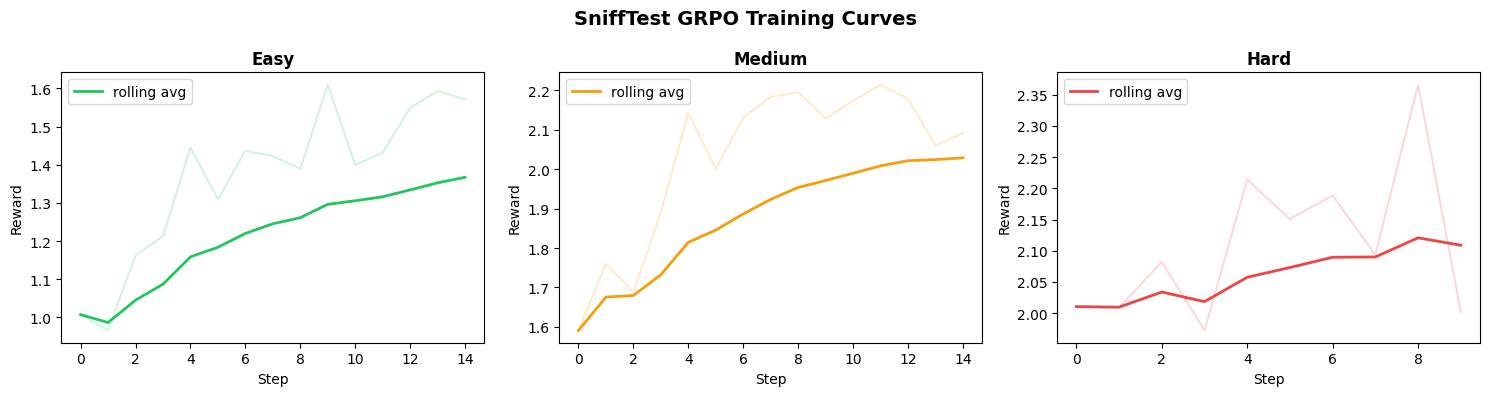

In [13]:
import matplotlib.pyplot as plt, json as _json
history = _json.loads((ARTIFACT_DIR/"reward_history.json").read_text())
colors = {"easy":"#22c55e","medium":"#f59e0b","hard":"#ef4444"}
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, level in zip(axes,["easy","medium","hard"]):
    rs = [e["reward"] for e in history if e["level"]==level]
    if not rs: ax.set_title(level); continue
    w = 20
    rolling = [sum(rs[max(0,i-w):i+1])/min(i+1,w) for i in range(len(rs))]
    ax.plot(rs, alpha=0.2, color=colors[level])
    ax.plot(rolling, color=colors[level], lw=2, label="rolling avg")
    ax.set_title(level.capitalize(), fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel("Reward")
    ax.legend()
plt.suptitle("SniffTest GRPO Training Curves", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()
